# Assignment 2: Code Summarization via LSTM

**Course:** GenAI for Software Development (CSCI 455/555)
**Instructor:** Prof. Antonio Mastropaolo

### How to run
1. Install dependencies (run the cell below **once**, then you never need to again)
2. Run all cells top to bottom
3. The GitHub mining section takes hours depending on your connection
4. Training checkpoints are saved to `checkpoints/` so you can resume if interrupted

### Directory layout
```
assignment-2-LSTM/
├── assignment-2-LSTM.ipynb
├── get_codet5_embeddings.py      ← provided by instructor
├── requirements_side.txt         ← SIDE requirements (provided by instructor)
├── dataset/
│   ├── train_code.txt
│   ├── train_summary.txt
│   ├── val_code.txt
│   ├── val_summary.txt
│   ├── train_code.pt
│   ├── train_summary.pt
│   ├── val_code.pt
│   └── val_summary.pt
├── checkpoints/
└── predictions/
```

## Cell 1: Install Dependencies

Run this cell once. After it finishes, **restart the kernel** (Kernel → Restart), then run from Cell 2 onward.

For CUDA on Windows with an NVIDIA GPU, torch is installed from the official CUDA 11.8 wheel. If you have a different CUDA version check https://pytorch.org/get-started/locally/ and swap the index URL.

In [1]:
# Run this cell once, then restart the kernel (Kernel → Restart).
# After restarting, skip this cell and run from Cell 2 onward.

# %pip always installs into the active kernel — no path issues on Windows
%pip uninstall -y torchao
%pip install "numpy<2"

# PyTorch — CUDA 11.8 wheels for Windows + NVIDIA GPU
# If your CUDA version differs, replace cu118 with e.g. cu121
%pip install torch==2.2.0 torchvision --index-url https://download.pytorch.org/whl/cu118

%pip install transformers==4.46.0 tokenizers==0.20.3 sentencepiece==0.1.99
%pip install tqdm==4.65.0
%pip install javalang pandas requests
%pip install sacrebleu evaluate bert_score nltk

print('\nDone. Restart the kernel now (Kernel → Restart), then skip this cell.')

Note: you may need to restart the kernel to use updated packages.


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeableNote: you may need to restart the kernel to use updated packages.

Looking in indexes: https://download.pytorch.org/whl/cu118
Defaulting to user installation because normal site-packages is not writeableNote: you may need to restart the kernel to use updated packages.


  error: subprocess-exited-with-error
  
  Getting requirements to build wheel did not run successfully.
  exit code: 1
  
  [31 lines of output]
  Traceback (most recent call last):
    File "C:\Users\hewas\AppData\Roaming\Python\Python312\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 389, in <module>
      main()
    File "C:\Users\hewas\AppData\Roaming\Python\Python312\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 373, in main
      json_out["return_val"] = hook(**hook_input["kwargs"])
                               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    File "C:\Users\hewas\AppData\Roaming\Python\Python312\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 143, in get_requires_for_build_wheel
      return hook(config_settings)
             ^^^^^^^^^^^^^^^^^^^^^
    File "C:\Users\hewas\AppData\Local\Temp\pip-build-env-k87u6n_6\overlay\Lib\site-packages\setuptools\build_meta.py", line 333, in get_requires


  Using cached transformers-4.46.0-py3-none-any.whl.metadata (44 kB)
  Using cached tokenizers-0.20.3-cp312-none-win_amd64.whl.metadata (6.9 kB)
  Using cached sentencepiece-0.1.99.tar.gz (2.6 MB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'error'
Defaulting to user installation because normal site-packages is not writeable
  Using cached tqdm-4.65.0-py3-none-any.whl.metadata (56 kB)
Using cached tqdm-4.65.0-py3-none-any.whl (77 kB)
  Attempting uninstall: tqdm
    Found existing installation: tqdm 4.67.3
    Uninstalling tqdm-4.67.3:
      Successfully uninstalled tqdm-4.67.3
Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
datasets 4.7.0 requires tqdm>=4.66.3, but you have tqdm 4.65.0 which is incompatible.
pyppeteer 2.0.0 requires urllib3<2.0.0,>=1.25.8, but you have urllib3 2.2.2 which is incompatible.
pyppeteer 2.0.0 requires websockets<11.0,>=10.0, but you have websockets 13.1 which is incompatible.


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeableNote: you may need to restart the kernel to use updated packages.

Done. Restart the kernel now (Kernel → Restart), then skip this cell.

  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
Using cached tqdm-4.67.3-py3-none-any.whl (78 kB)
  Attempting uninstall: tqdm
    Found existing installation: tqdm 4.65.0
    Uninstalling tqdm-4.65.0:
      Successfully uninstalled tqdm-4.65.0


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pyppeteer 2.0.0 requires urllib3<2.0.0,>=1.25.8, but you have urllib3 2.2.2 which is incompatible.
pyppeteer 2.0.0 requires websockets<11.0,>=10.0, but you have websockets 13.1 which is incompatible.


## Cell 2: Imports

In [2]:
import os
import subprocess
import json
import random
import shutil
import re
from pathlib import Path

import requests
import pandas as pd
import javalang
from javalang.tokenizer import tokenize

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from collections import Counter
from tqdm import tqdm
import numpy as np

from sacrebleu.metrics import BLEU
import evaluate as hf_evaluate
import bert_score

import nltk
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

import transformers, tokenizers as _tok
print(f'torch:        {torch.__version__}')
print(f'transformers: {transformers.__version__}')
print(f'tokenizers:   {_tok.__version__}')
print(f'numpy:        {np.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

C:\Users\hewas\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


torch:        2.2.0+cu118
transformers: 4.45.2
tokenizers:   0.20.1
numpy:        1.26.4
CUDA available: True
GPU: NVIDIA GeForce RTX 4050 Laptop GPU


## Cell 3: Configuration

| Parameter | Value | Notes |
|---|---|---|
| BATCH_SIZE | 32 | Pairs per training step |
| MAX_SRC_LEN | 256 | Max tokens for Java method (CodeT5+ limit is 512) |
| MAX_TGT_LEN | 128 | Max tokens for summary |
| HIDDEN_DIM | 256 | LSTM hidden state size; CodeT5+ 768-dim projected down to this |
| NUM_EPOCHS | 10 | Max epochs; early stopping will usually fire sooner |
| EVAL_STEPS | 500 | Evaluate on val set every N steps |
| PATIENCE | 3 | Stop after this many evals with no BLEU-1 improvement |

In [3]:
BATCH_SIZE   = 32
MAX_SRC_LEN  = 256
MAX_TGT_LEN  = 128
HIDDEN_DIM   = 256
NUM_EPOCHS   = 12
EVAL_STEPS   = 500
PATIENCE     = 3
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# All output goes under these local directories (created automatically)
CLONE_DIR  = 'java_repos'
OUTPUT_DIR = 'dataset'
CKPT_DIR   = 'checkpoints'
PRED_DIR   = 'predictions'

for d in [CLONE_DIR, OUTPUT_DIR, CKPT_DIR, PRED_DIR]:
    os.makedirs(d, exist_ok=True)

print(f'Device: {DEVICE}')
print('Directories ready.')

Device: cuda
Directories ready.


---
## Part 1: Corpus Construction

We mine ~50,000 Java method–docstring pairs from public GitHub repositories.

**Pipeline:**
1. Fetch top-starred Java repos from GitHub API (non-forks only, >100 stars)
2. Shallow-clone each repository (`--depth 1`)
3. Select up to 20 `.java` files per repo (excluding test/example dirs)
4. Parse with `javalang`, extract methods that have a Javadoc comment
5. Strip `@param`/`@return`/`@throws` tags, keep first-sentence summary, lowercase
6. Filter boilerplate, non-ASCII, short methods
7. Deduplicate, split by repo rank into train/val/test
8. Write to `.txt` files (one sample per line)

**Data sources:** Public GitHub repositories, Java language, >100 stars, non-forked.  
**Pre-processing:** Methods flattened to single whitespace-normalised lines; summaries lowercased with Javadoc markup removed.

### Fetch Repository List

In [4]:
def fetch_top_java_repos(num_repos=700, per_page=100):
    """
    Fetch top-starred Java repositories from GitHub API.
    Skips forked repos to avoid duplicate code.
    """
    repos = []
    page = 1
    headers = {}
    # Optional: add a GitHub token to avoid rate limiting
    # headers = {'Authorization': 'token YOUR_GITHUB_TOKEN'}

    while len(repos) < num_repos:
        url = 'https://api.github.com/search/repositories'
        params = {
            'q': 'language:java stars:>100',
            'sort': 'stars', 'order': 'desc',
            'per_page': per_page, 'page': page
        }
        response = requests.get(url, params=params, headers=headers)
        if response.status_code == 403:
            print('Rate limited — add a GitHub token or wait a minute.')
            break
        if response.status_code != 200:
            print(f'Error: {response.status_code}')
            break
        items = response.json().get('items', [])
        if not items:
            break
        for item in items:
            if item.get('fork', False):
                continue
            repos.append({
                'full_name': item['full_name'],
                'clone_url': item['clone_url'],
                'stars': item['stargazers_count'],
            })
        page += 1
        if len(repos) >= num_repos:
            break
    return repos[:num_repos]

print('Fetching top Java repositories from GitHub...')
repo_data = fetch_top_java_repos(num_repos=800)
df_repos = pd.DataFrame(repo_data)
df_repos['repo_rank'] = range(1, len(df_repos) + 1)
repo_rank_lookup = dict(zip(df_repos['full_name'], df_repos['repo_rank']))
print(f'Fetched {len(df_repos)} repositories')
df_repos.head()

Fetching top Java repositories from GitHub...
Fetched 800 repositories


,full_name,clone_url,stars,repo_rank
0,Snailclimb/JavaGuide,https://github.com/Snailclimb/JavaGuide.git,154256,1
1,krahets/hello-algo,https://github.com/krahets/hello-algo.git,123286,2
2,GrowingGit/GitHub-Chinese-Top-Charts,https://github.com/GrowingGit/GitHub-Chinese-T...,106869,3
3,iluwatar/java-design-patterns,https://github.com/iluwatar/java-design-patter...,93802,4
4,macrozheng/mall,https://github.com/macrozheng/mall.git,83156,5


### Clone Repositories

Shallow clone (`--depth 1`) — we only need the current snapshot, not commit history.

In [8]:
def clone_repo(clone_url, dest_dir):
    """Shallow clone a repository. Returns True if successful."""
    try:
        if os.path.exists(dest_dir):
            shutil.rmtree(dest_dir)
        cmd = ['git', 'clone', '--depth', '1', '--quiet', clone_url, dest_dir]
        result = subprocess.run(cmd, capture_output=True, text=True, timeout=120)
        return result.returncode == 0
    except subprocess.TimeoutExpired:
        print(f'  Timeout: {clone_url}')
        return False
    except Exception as e:
        print(f'  Error: {e}')
        return False

cloned_repos, failed_repos = [], []
print(f'Cloning {len(df_repos)} repositories...\n')

for idx, row in df_repos.iterrows():
    repo_name = row['full_name']
    safe_name = repo_name.replace('/', '_')
    dest_dir  = os.path.join(CLONE_DIR, safe_name)
    print(f'[{idx+1}/{len(df_repos)}] {repo_name}...', end=' ', flush=True)
    if clone_repo(row['clone_url'], dest_dir):
        cloned_repos.append({'repo_name': repo_name, 'local_path': dest_dir, 'stars': row['stars']})
        print('done')
    else:
        failed_repos.append(repo_name)
        print('failed')

print(f'\nCloned: {len(cloned_repos)} | Failed: {len(failed_repos)}')

Cloning 800 repositories...

[1/800] Snailclimb/JavaGuide... done
[2/800] krahets/hello-algo... done
[3/800] GrowingGit/GitHub-Chinese-Top-Charts... done
[4/800] iluwatar/java-design-patterns... done
[5/800] macrozheng/mall... done
[6/800] spring-projects/spring-boot... failed
[7/800] doocs/advanced-java... done
[8/800] MisterBooo/LeetCodeAnimation... done
[9/800] elastic/elasticsearch...   Timeout: https://github.com/elastic/elasticsearch.git
failed
[10/800] NationalSecurityAgency/ghidra... done
[11/800] TheAlgorithms/Java... done
[12/800] kdn251/interviews... done
[13/800] spring-projects/spring-framework... failed
[14/800] termux/termux-app... done
[15/800] google/guava... done
[16/800] dbeaver/dbeaver... done
[17/800] ReactiveX/RxJava... done
[18/800] skylot/jadx... done
[19/800] jeecgboot/JeecgBoot... failed
[20/800] apache/dubbo... failed
[21/800] PhilJay/MPAndroidChart... done
[22/800] halo-dev/halo... done
[23/800] TeamNewPipe/NewPipe... done
[24/800] eugenp/tutorials... done
[

Exception in thread Thread-1066 (_readerthread):
Traceback (most recent call last):
  File "C:\Program Files\Python312\Lib\threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "C:\Users\hewas\AppData\Roaming\Python\Python312\site-packages\ipykernel\ipkernel.py", line 766, in run_closure
    _threading_Thread_run(self)
  File "C:\Program Files\Python312\Lib\threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "C:\Program Files\Python312\Lib\subprocess.py", line 1599, in _readerthread
    buffer.append(fh.read())
                  ^^^^^^^^^
  File "C:\Program Files\Python312\Lib\encodings\cp1252.py", line 23, in decode
    return codecs.charmap_decode(input,self.errors,decoding_table)[0]
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeDecodeError: 'charmap' codec can't decode byte 0x8f in position 46: character maps to <undefined>


failed
[522/800] jpush/aurora-imui... done
[523/800] ddd-by-examples/library... done
[524/800] Devlight/InfiniteCycleViewPager... done
[525/800] crazycodeboy/react-native-splash-screen... done
[526/800] springside/springside4... done
[527/800] 201206030/novel... done
[528/800] JakeWharton/u2020... done
[529/800] ElderDrivers/EdXposed... done
[530/800] wasabeef/Blurry... done
[531/800] hanks-zyh/HTextView... done
[532/800] microsoft/typespec... failed
[533/800] daimajia/AndroidImageSlider... done
[534/800] TommyLemon/Android-ZBLibrary... done
[535/800] osmandapp/OsmAnd... done
[536/800] hongyangAndroid/FlowLayout... done
[537/800] baidu/uid-generator... done
[538/800] apache/hbase... done
[539/800] alibaba/jetcache... done
[540/800] amlcurran/ShowcaseView... done
[541/800] mik3y/usb-serial-for-android... done
[542/800] alibaba/QLExpress... done
[543/800] hneemann/Digital... done
[544/800] nhaarman/ListViewAnimations... done
[545/800] knightliao/disconf... done
[546/800] danikula/Android

Exception in thread Thread-1412 (_readerthread):
Traceback (most recent call last):
  File "C:\Program Files\Python312\Lib\threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "C:\Users\hewas\AppData\Roaming\Python\Python312\site-packages\ipykernel\ipkernel.py", line 766, in run_closure
    _threading_Thread_run(self)
  File "C:\Program Files\Python312\Lib\threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "C:\Program Files\Python312\Lib\subprocess.py", line 1599, in _readerthread
    buffer.append(fh.read())
                  ^^^^^^^^^
  File "C:\Program Files\Python312\Lib\encodings\cp1252.py", line 23, in decode
    return codecs.charmap_decode(input,self.errors,decoding_table)[0]
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeDecodeError: 'charmap' codec can't decode byte 0x90 in position 160: character maps to <undefined>


failed
[695/800] spring-attic/spring-security-oauth... done
[696/800] hansonwang99/Spring-Boot-In-Action... done
[697/800] cjlin1/libsvm... done
[698/800] SPLWare/esProc... done
[699/800] pardom-zz/ActiveAndroid... done
[700/800] jgilfelt/chuck... done
[701/800] charles2gan/GDA-android-reversing-Tool... done
[702/800] bytedeco/javacpp... done
[703/800] bepass-org/oblivion... done
[704/800] 981011512/--... done
[705/800] Heeexy/SpringBoot-Shiro-Vue... done
[706/800] JZ-Darkal/AndroidHttpCapture... done
[707/800] ant-media/Ant-Media-Server... done
[708/800] wdullaer/MaterialDateTimePicker... done
[709/800] discord-jda/JDA... done
[710/800] rememberber/WePush... done
[711/800] karma9874/AndroRAT... done
[712/800] zongzibinbin/MallChat... done
[713/800] CalebFenton/simplify... done
[714/800] gabrielemariotti/cardslib... done
[715/800] chewiebug/GCViewer... done
[716/800] romandanylyk/PageIndicatorView... done
[717/800] yasserg/crawler4j... done
[718/800] RedSpider1/concurrent... done
[719/


### Find and Select Java Files

In [45]:
CLASSES_PER_REPO = 100
def find_java_files(repo_path):
    java_files = []
    exclude = {'test', 'tests', 'example', 'examples', 'sample', 'samples', 'demo', 'generated'}
    for root, dirs, files in os.walk(repo_path):
        # Check only individual directory names, not the full path string
        path_parts = set(Path(root).parts)
        if path_parts & exclude:
            continue
        for f in files:
            if f.endswith('.java'):
                java_files.append(os.path.join(root, f))
    return java_files

repo_java_files = {}
all_selected_files = []

for repo_info in cloned_repos:
    repo_name = repo_info['repo_name']
    java_files = find_java_files(repo_info['local_path'])
    if not java_files:
        continue
    selected = random.sample(java_files, min(len(java_files), CLASSES_PER_REPO))
    repo_java_files[repo_name] = selected
    all_selected_files.extend(selected)

print(f'Total .java files selected: {len(all_selected_files)}')

Total .java files selected: 53600


### Parse Methods and Extract Javadoc Summaries

Key addition vs Lab 01: we capture the Javadoc comment (`node.documentation`) above each method declaration and clean it into a one-line summary. Both code and summary are written to separate `.txt` files for the CodeT5+ embedding script.

In [46]:
def read_file_content(file_path):
    """Read file with encoding fallbacks."""
    for enc in ['utf-8', 'latin-1', 'cp1252']:
        try:
            with open(file_path, 'r', encoding=enc) as f:
                return f.read()
        except UnicodeDecodeError:
            continue
    return None


def extract_method_source(method_node, lines):
    """Extract method source by counting braces."""
    try:
        start = method_node.position.line - 1
        brace_count, started, end = 0, False, start
        for i in range(start, len(lines)):
            for ch in lines[i]:
                if ch == '{': brace_count += 1; started = True
                elif ch == '}': brace_count -= 1
            if started and brace_count == 0:
                end = i; break
        return '\n'.join(lines[start:end + 1])
    except Exception:
        return None


def clean_javadoc(docstring):
    """
    Extract first-sentence summary from a Javadoc comment.
    Strips /** */ delimiters, leading asterisks, and @tag lines.
    Returns lowercased, whitespace-normalised string, or None if empty.
    """
    text = re.sub(r'/\*\*|\*/', '', docstring)
    text = re.sub(r'^\s*\*\s?', '', text, flags=re.MULTILINE)
    text = re.sub(r'@\w+.*', '', text, flags=re.MULTILINE)
    text = ' '.join(text.split()).strip().lower()
    return text if text else None


def extract_pairs_from_file(file_path, repo_name):
    """Parse a Java file and return (tokenized_code, summary) pairs."""
    pairs = []
    source = read_file_content(file_path)
    if source is None:
        return pairs
    lines = source.split('\n')
    try:
        tree = javalang.parse.parse(source)
        for _, node in tree.filter(javalang.tree.MethodDeclaration):
            if node.documentation is None:
                continue
            summary = clean_javadoc(node.documentation)
            if not summary:
                continue
            method_src = extract_method_source(node, lines)
            if not method_src:
                continue
            try:
                tokens = list(tokenize(method_src))
                tokenized = ' '.join(t.value for t in tokens)
            except Exception:
                continue
            pairs.append({
                'repo': repo_name,
                'method_name': node.name,
                'tokenized_code': tokenized,
                'summary': summary,
                'token_count': len(tokens)
            })
    except Exception:
        pass
    return pairs


all_pairs = []
print('Extracting method–docstring pairs...')
for repo_info in tqdm(cloned_repos, desc='Repos'):
    for file_path in repo_java_files.get(repo_info['repo_name'], []):
        all_pairs.extend(extract_pairs_from_file(file_path, repo_info['repo_name']))

print(f'Total pairs extracted: {len(all_pairs)}')

Extracting method–docstring pairs...


Repos: 100%|█████████████████████████████████████████████████████████████████████████| 736/736 [12:40<00:00,  1.03s/it]

Total pairs extracted: 95521


### Filter, Deduplicate, and Split

In [48]:
def contains_non_ascii(text):
    try: text.encode('ascii'); return False
    except UnicodeEncodeError: return True


def contains_boilerplate(method_name):
    """
    Checks if the method name is or starts with the name of common boilerplate methods (getters, setters).
    This reduces spurious results because getters/setters are almost identical among classes and also common,
    therefore if we drop them, we'll keep methods that are more unique.
    """
    name = method_name.lower()
    return any(name == b or name.startswith(b) for b in ('get', 'set'))


MIN_TOKENS       = 5
MIN_SUMMARY_WORDS = 2

# Filter
filtered = [
    p for p in all_pairs
    if not contains_non_ascii(p['tokenized_code'])
    and not contains_non_ascii(p['summary'])
    and p['token_count'] >= MIN_TOKENS
    and not contains_boilerplate(p['method_name'])
    and len(p['summary'].split()) >= MIN_SUMMARY_WORDS
]
print(f'After filtering: {len(filtered)} (was {len(all_pairs)})')

# Deduplicate on code
seen, unique = set(), []
for p in filtered:
    if p['tokenized_code'] not in seen:
        seen.add(p['tokenized_code'])
        p['repo_rank'] = repo_rank_lookup.get(p['repo'], 9999)
        unique.append(p)
print(f'After dedup:     {len(unique)}')

# Split by repo rank
random.seed(42)
train_data, val_data, test_data = [], [], []
for p in unique:
    r = p['repo_rank']
    if   1 <= r <= 650: train_data.append(p)    # 100 more repos for train
    elif 671 <= r <= 720: val_data.append(p)
    elif 721 <= r <= 800: test_data.append(p)

random.shuffle(val_data)
val_data = val_data[:1000]  # cap at 1000 as required

print(f'\nDataset split:')
print(f'  Train: {len(train_data):,}')
print(f'  Val:   {len(val_data):,}')
print(f'  Test:  {len(test_data):,} (instructor test set used for final eval)')

After filtering: 50131 (was 95521)
After dedup:     47418

Dataset split:
  Train: 39,526
  Val:   1,000
  Test:  3,925 (instructor test set used for final eval)


### Save to .txt Files

One sample per line, whitespace-normalised. Code and summaries in separate files as required by the embedding script.

In [59]:
def save_txt(data, key, filename):
    filepath = os.path.join(OUTPUT_DIR, filename)
    with open(filepath, 'w', encoding='utf-8') as f:
        for item in data:
            line = ' '.join(item[key].split())
            f.write(line + '\n')
    print(f'  {filepath}  ({len(data):,} lines)')
    return filepath

print('Saving .txt files...')
save_txt(train_data, 'tokenized_code', 'train_code.txt')
save_txt(train_data, 'summary',        'train_summary.txt')
save_txt(val_data,   'tokenized_code', 'val_code.txt')
save_txt(val_data,   'summary',        'val_summary.txt')

with open(os.path.join(OUTPUT_DIR, 'metadata.json'), 'w') as f:
    json.dump({
        'train': len(train_data), 'val': len(val_data), 'test': len(test_data),
        'split_rule': 'repo_rank 1-500=train, 501-600=val, 601-700=test',
        'sources': list({p['repo'] for p in train_data})[:30]
    }, f, indent=2)
print('Saved metadata.json')

Saving .txt files...
  dataset\train_code.txt  (39,526 lines)
  dataset\train_summary.txt  (39,526 lines)
  dataset\val_code.txt  (1,000 lines)
  dataset\val_summary.txt  (1,000 lines)
Saved metadata.json


---
## Part 2: CodeT5+ Embeddings

Run the instructor-provided script to tokenize data and extract the pretrained embedding matrix.

**Run these in a terminal** (or as shell cells) from the notebook directory:

```bash
python get_codet5_embeddings.py --input dataset/train_code.txt --output dataset/train_code.pt --max_length 256
python get_codet5_embeddings.py --input dataset/train_summary.txt --output dataset/train_summary.pt --max_length 128
python get_codet5_embeddings.py --input dataset/val_code.txt --output dataset/val_code.pt --max_length 256
python get_codet5_embeddings.py --input dataset/val_summary.txt --output dataset/val_summary.pt --max_length 128
```

`max_length=256` for code (covers >95% of methods), `max_length=128` for summaries. Both within CodeT5+'s 512-token limit.

Then run the cell below to load them.

In [60]:
# Run embedding script from within the notebook if preferred
import sys
script = 'get_codet5_embeddings.py'
runs = [
    (f'{OUTPUT_DIR}/train_code.txt',    f'{OUTPUT_DIR}/train_code.pt',    256),
    (f'{OUTPUT_DIR}/train_summary.txt', f'{OUTPUT_DIR}/train_summary.pt', 128),
    (f'{OUTPUT_DIR}/val_code.txt',      f'{OUTPUT_DIR}/val_code.pt',      256),
    (f'{OUTPUT_DIR}/val_summary.txt',   f'{OUTPUT_DIR}/val_summary.pt',   128),
]
for inp, out, maxlen in runs:
    if os.path.exists(out):
        print(f'Already exists, skipping: {out}')
        continue
    print(f'Running embedding script: {inp} → {out}')
    result = subprocess.run(
        [sys.executable, script, '--input', inp, '--output', out, '--max_length', str(maxlen)],
        capture_output=True, text=True
    )
    if result.returncode != 0:
        print(f'  ERROR: {result.stderr[-500:]}')
    else:
        print(f'  Done.')

Running embedding script: dataset/train_code.txt → dataset/train_code.pt
  Done.
Running embedding script: dataset/train_summary.txt → dataset/train_summary.pt
  Done.
Running embedding script: dataset/val_code.txt → dataset/val_code.pt
  Done.
Running embedding script: dataset/val_summary.txt → dataset/val_summary.pt
  Done.


In [61]:
train_code_data    = torch.load(f'{OUTPUT_DIR}/train_code.pt',    map_location='cpu', weights_only=False)
train_summary_data = torch.load(f'{OUTPUT_DIR}/train_summary.pt', map_location='cpu', weights_only=False)
val_code_data      = torch.load(f'{OUTPUT_DIR}/val_code.pt',      map_location='cpu', weights_only=False)
val_summary_data   = torch.load(f'{OUTPUT_DIR}/val_summary.pt',   map_location='cpu', weights_only=False)

embedding_matrix = train_code_data['embedding_matrix']
pad_id        = int(train_code_data['pad_token_id'])
eos_id        = int(train_code_data['eos_token_id'])
vocab_size    = int(train_code_data['vocab_size'])
embedding_dim = int(train_code_data['embedding_dim'])

print(f'Vocab size:    {vocab_size:,}')
print(f'Embedding dim: {embedding_dim}')
print(f'pad_id: {pad_id} | eos_id: {eos_id}')
print(f'Train samples: {len(train_code_data["token_ids"]):,}')
print(f'Val samples:   {len(val_code_data["token_ids"]):,}')

Vocab size:    32,100
Embedding dim: 768
pad_id: 0 | eos_id: 2
Train samples: 39,526
Val samples:   1,000


---
## Part 3: Dataset and DataLoader

`SumDataset` pairs source (code) token IDs with target (summary) token IDs from the `.pt` files. The `isinstance` check in `__getitem__` handles the case where the embedding script stores IDs as plain Python lists rather than tensors — `pad_sequence` requires tensors.

In [62]:
class SumDataset(Dataset):
    def __init__(self, code_data, summary_data):
        self.src_ids = code_data['token_ids']
        self.tgt_ids = summary_data['token_ids']
        assert len(self.src_ids) == len(self.tgt_ids)

    def __len__(self):
        return len(self.src_ids)

    def __getitem__(self, idx):
        src = self.src_ids[idx]
        tgt = self.tgt_ids[idx]
        if not isinstance(src, torch.Tensor):
            src = torch.tensor(src, dtype=torch.long)
        if not isinstance(tgt, torch.Tensor):
            tgt = torch.tensor(tgt, dtype=torch.long)
        return src, tgt


def collate_fn(batch):
    src, tgt = zip(*batch)
    return (pad_sequence(src, batch_first=True, padding_value=pad_id),
            pad_sequence(tgt, batch_first=True, padding_value=pad_id))


train_dataset = SumDataset(train_code_data, train_summary_data)
val_dataset   = SumDataset(val_code_data,   val_summary_data)

train_loader = DataLoader(train_dataset, BATCH_SIZE, shuffle=True,  collate_fn=collate_fn, num_workers=0)
val_loader   = DataLoader(val_dataset,   BATCH_SIZE, shuffle=False, collate_fn=collate_fn, num_workers=0)

# Sanity check
src_b, tgt_b = next(iter(train_loader))
print(f'Train batches: {len(train_loader)}')
print(f'Val batches:   {len(val_loader)}')
print(f'src shape: {src_b.shape} | tgt shape: {tgt_b.shape} | dtype: {src_b.dtype}')

Train batches: 1236
Val batches:   32
src shape: torch.Size([32, 256]) | tgt shape: torch.Size([32, 128]) | dtype: torch.int64


---
## Part 4: Model

Encoder-decoder LSTM following the same structure as the class notebook. Encoder reads the Java method tokens and compresses to a hidden state; decoder generates the natural language summary token by token.

- `forward()`: training with **teacher forcing**
- `generate()`: inference with **autoregressive decoding**

CodeT5+ embeddings (768-dim) are projected down to `HIDDEN_DIM=256` via a linear layer before the LSTM.

In [90]:
class Model(nn.Module):
    def __init__(self, vocab_size, embedding_matrix, freeze_embeddings=False):
        super().__init__()

        # Load pretrained CodeT5+ embeddings as per assignment spec
        self.embed = nn.Embedding.from_pretrained(
            embedding_matrix, freeze=freeze_embeddings, padding_idx=pad_id
        )
        # Project from CodeT5+ 768-dim down to LSTM hidden dim
        self.projection = nn.Linear(embedding_dim, HIDDEN_DIM)

        self.dropout = nn.Dropout(0.2)
        self.encoder = nn.LSTM(HIDDEN_DIM, HIDDEN_DIM, 2, batch_first=True, dropout=0.2)
        self.decoder = nn.LSTM(HIDDEN_DIM, HIDDEN_DIM, 2, batch_first=True, dropout=0.2)
        self.out = nn.Linear(HIDDEN_DIM, vocab_size)

    def _embed(self, x):
        return self.dropout(self.projection(self.embed(x)))
        
    def forward(self, src, tgt, teacher_forcing_ratio=0.5):
        _, hidden = self.encoder(self._embed(src))
        
        # First pass: get all decoder outputs at once (fast, vectorized)
        embedded_tgt = self._embed(tgt)
        output, _ = self.decoder(embedded_tgt, hidden)
        logits = self.out(output)  # (B, T, vocab)
        
        if teacher_forcing_ratio >= 1.0:
            return logits  # pure teacher forcing, done
        
        # Second pass: replace some steps with model's own predictions
        # Sample a mask: True = use model output, False = use ground truth
        mask = torch.rand(tgt.size(1), device=src.device) > teacher_forcing_ratio  # (T,)
        
        if mask.any():
            pred_ids = logits.detach().argmax(-1)  # (B, T)
            # Build mixed input: where mask=True, use pred; else use tgt
            mixed_input = torch.where(mask.unsqueeze(0), pred_ids, tgt)  # (B, T)
            embedded_mixed = self._embed(mixed_input)
            output, _ = self.decoder(embedded_mixed, hidden)
            logits = self.out(output)
        
        return logits

    def generate(self, src, max_len=MAX_TGT_LEN):
        _, hidden = self.encoder(self._embed(src))
        outputs = []
        bos_id = tokenizer.bos_token_id  # or tokenizer.cls_token_id
        input_tok = torch.tensor([[bos_id]], device=src.device)

        for _ in range(max_len):
            out, hidden = self.decoder(self._embed(input_tok), hidden)
            pred = self.out(out).argmax(-1)
            if pred.item() == eos_id:
                break
            outputs.append(pred.item())
            input_tok = pred
        return outputs


model = Model(vocab_size, embedding_matrix, freeze_embeddings=False).to(DEVICE)

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Parameters: {total:,} total | {trainable:,} trainable')

Parameters: 35,204,708 total | 35,204,708 trainable


---
## Part 5: Evaluation Helpers

`compute_bleu1` is used during training for early stopping. The full metric suite (BLEU-1/2/3/4, METEOR, BERTScore, SIDE) runs only once on the final test set.

In [91]:
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained('Salesforce/codet5p-220m')

bos_id = tokenizer.bos_token_id
def ids_to_text(ids):
    skip = {pad_id, eos_id, bos_id}
    filtered = [i for i in ids if i not in skip]
    return tokenizer.decode(filtered, skip_special_tokens=True,
                            clean_up_tokenization_spaces=True)


def compute_bleu1(model, loader, n_samples=200):
    """BLEU-1 on up to n_samples. Used for early stopping."""
    model.eval()
    preds, refs = [], []
    count = 0
    with torch.no_grad():
        for src, tgt in loader:
            src, tgt = src.to(DEVICE), tgt.to(DEVICE)
            for i in range(src.size(0)):
                if count >= n_samples: break
                preds.append(ids_to_text(model.generate(src[i:i+1])))
                refs.append(ids_to_text(tgt[i].tolist()))
                count += 1
            if count >= n_samples: break
    metric = BLEU(max_ngram_order=1, effective_order=True)
    score = metric.corpus_score(preds, [refs]).score
    model.train()
    return score

---
## Part 6: Training

Early stopping on validation BLEU-1 with patience=3. Best checkpoint saved to `checkpoints/`.

In [92]:
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()), lr=0.001
)
criterion = nn.CrossEntropyLoss(ignore_index=pad_id)

best_bleu1   = 0
patience_ctr = 0
save_path    = f'{CKPT_DIR}/lstm_codet5_summarization.pt'

steps_per_epoch = len(train_loader)
total_steps     = NUM_EPOCHS * steps_per_epoch
step = 0
running_loss = 0
train_losses, val_bleu1s = [], []
PATIENCE = 10

progress = tqdm(total=total_steps, desc='Training')
for epoch in range(NUM_EPOCHS):
    model.train()
    for src, tgt in train_loader:
        src, tgt = src.to(DEVICE), tgt.to(DEVICE)

        output = model(src, tgt[:, :-1])
        loss   = criterion(output.reshape(-1, output.size(-1)),
                           tgt[:, 1:].reshape(-1))

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        step += 1
        running_loss += loss.item()

        if step % 50 == 0:
            avg = running_loss / 50
            train_losses.append((step, avg))
            progress.set_postfix({'loss': f'{avg:.3f}', 'epoch': f'{step/steps_per_epoch:.2f}'})
            running_loss = 0

        progress.update(1)

        if step % EVAL_STEPS == 0:
            bleu1 = compute_bleu1(model, val_loader)
            val_bleu1s.append((step, bleu1))
            tqdm.write(f'Step {step}/{total_steps} | Val BLEU-1 = {bleu1:.2f} | epoch {step/steps_per_epoch:.2f}', end='')

            if bleu1 > best_bleu1:
                best_bleu1   = bleu1
                patience_ctr = 0
                torch.save(model.state_dict(), save_path)
                tqdm.write(' | Saved ✓')
            else:
                patience_ctr += 1
                tqdm.write(f' | Patience {patience_ctr}/{PATIENCE}')
                #if patience_ctr >= PATIENCE:
                 #   tqdm.write(f'\nEarly stopping at step {step}. Best BLEU-1: {best_bleu1:.2f}')
                  #  progress.close()
                   # break
            model.train()
    else:
        continue
    break

progress.close()
print(f'\nBest Val BLEU-1: {best_bleu1:.2f}')


Training:   2%|▊                                         | 266/14832 [09:24<8:35:15,  2.12s/it, loss=6.422, epoch=0.20]

Training:   3%|█▍                                          | 500/14832 [01:55<51:21,  4.65it/s, loss=5.843, epoch=0.40]
                                                                                                                    
Training:   3%|█▍                                          | 500/14832 [02:30<51:21,  4.65it/s, loss=5.843, epoch=0.40]

Step 500/14832 | Val BLEU-1 = 1.34 | epoch 0.40


                                                                                                                    
Training:   3%|█▍                                       | 501/14832 [02:30<42:35:56, 10.70s/it, loss=5.843, epoch=0.40]

 | Saved ✓



Training:   7%|██▉                                        | 1000/14832 [04:25<55:38,  4.14it/s, loss=5.358, epoch=0.81]
                                                                                                                    
Training:   7%|██▉                                        | 1000/14832 [04:32<55:38,  4.14it/s, loss=5.358, epoch=0.81]
                                                                                                                    
Training:   7%|██▉                                        | 1000/14832 [04:32<55:38,  4.14it/s, loss=5.358, epoch=0.81]

...

Step 14500/14832 | Val BLEU-1 = 9.18 | epoch 11.73


                                                                                                                    
Training:  98%|████████████████████████████████████████ | 14500/14832 [59:19<01:10,  4.70it/s, loss=3.890, epoch=11.73]

 | Saved ✓



Training: 100%|███████████████████████████████████████| 14832/14832 [1:00:31<00:00,  4.08it/s, loss=3.890, epoch=11.97]


Best Val BLEU-1: 9.18


### Loss Convergence Plot

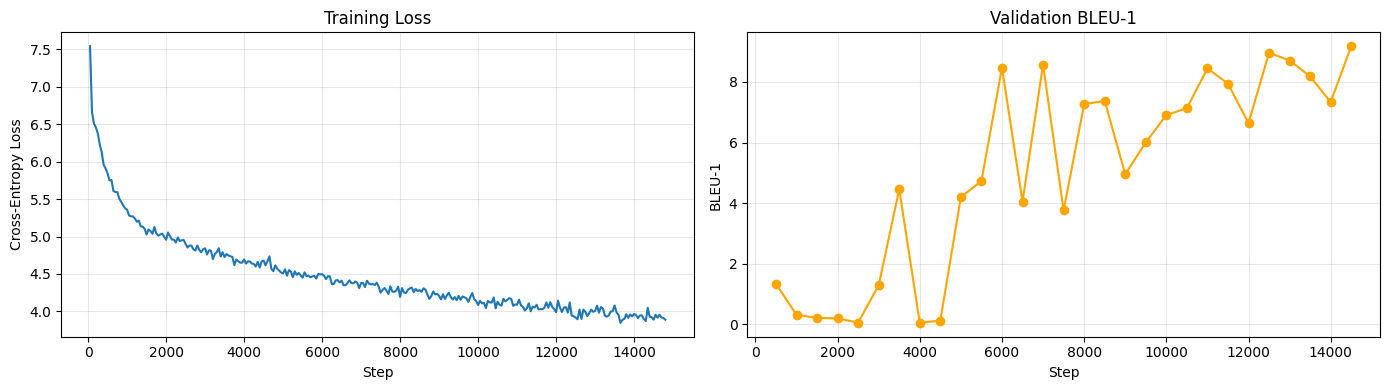

In [93]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

if train_losses:
    steps_l, losses_l = zip(*train_losses)
    ax1.plot(steps_l, losses_l)
    ax1.set_xlabel('Step'); ax1.set_ylabel('Cross-Entropy Loss')
    ax1.set_title('Training Loss'); ax1.grid(True, alpha=0.3)

if val_bleu1s:
    steps_b, bleus_b = zip(*val_bleu1s)
    ax2.plot(steps_b, bleus_b, color='orange', marker='o')
    ax2.set_xlabel('Step'); ax2.set_ylabel('BLEU-1')
    ax2.set_title('Validation BLEU-1'); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{CKPT_DIR}/loss_curve.png', dpi=150)
plt.show()

---
## Part 7: Test Set Evaluation

Load the best checkpoint, run on the instructor-provided 1,000-sample test set. Used **once only** for final reporting — not for tuning.

In [94]:
# Load best checkpoint
checkpoint = torch.load(save_path, map_location=DEVICE, weights_only=False)
model = Model(vocab_size, embedding_matrix, freeze_embeddings=False).to(DEVICE)
model.load_state_dict(checkpoint)
model.eval()
print(f'Loaded checkpoint from {save_path}')

Loaded checkpoint from checkpoints/lstm_codet5_summarization.pt


In [95]:
# Run embedding script from within the notebook if preferred
script = 'get_codet5_embeddings.py'
runs = [
    (f'{OUTPUT_DIR}/sample_code.txt',    f'{OUTPUT_DIR}/test_code.pt',    256),
    (f'{OUTPUT_DIR}/sample_summary.txt', f'{OUTPUT_DIR}/test_summary.pt', 128),
]
for inp, out, maxlen in runs:
    if os.path.exists(out):
        print(f'Already exists, skipping: {out}')
        continue
    print(f'Running embedding script: {inp} → {out}')
    result = subprocess.run(
        [sys.executable, script, '--input', inp, '--output', out, '--max_length', str(maxlen)],
        capture_output=True, text=True
    )
    if result.returncode != 0:
        print(f'  ERROR: {result.stderr[-500:]}')
    else:
        print(f'  Done.')

Already exists, skipping: dataset/test_code.pt
Already exists, skipping: dataset/test_summary.pt


In [96]:
# Run instructor embedding script on the test set first:
# python get_codet5_embeddings.py --input test_code.txt --output dataset/test_code.pt --max_length 256
# python get_codet5_embeddings.py --input test_summary.txt --output dataset/test_summary.pt --max_length 128

test_code_data    = torch.load(f'{OUTPUT_DIR}/test_code.pt',    map_location='cpu', weights_only=False)
test_summary_data = torch.load(f'{OUTPUT_DIR}/test_summary.pt', map_location='cpu', weights_only=False)

test_dataset = SumDataset(test_code_data, test_summary_data)
test_loader  = DataLoader(test_dataset, BATCH_SIZE, shuffle=False, collate_fn=collate_fn, num_workers=0)
print(f'Test samples: {len(test_dataset)}')

Test samples: 5


## Generate Predictions

In [97]:
predictions, references = [], []

with torch.no_grad():
    for src, tgt in tqdm(test_loader, desc='Generating'):
        src, tgt = src.to(DEVICE), tgt.to(DEVICE)
        for i in range(src.size(0)):
            predictions.append(ids_to_text(model.generate(src[i:i+1])))
            references.append(ids_to_text(tgt[i].tolist()))

print(f'Generated {len(predictions)} predictions')

Generating: 100%|████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  2.35it/s]

Generated 5 predictions


## Evaluation Metrics

In [98]:
# BLEU 1–4
bleu_scores = {}
for n in [1, 2, 3, 4]:
    result = BLEU(max_ngram_order=n, effective_order=True).corpus_score(predictions, [references])
    bleu_scores[f'BLEU-{n}'] = round(result.score, 4)
print('BLEU:', bleu_scores)

BLEU: {'BLEU-1': 18.75, 'BLEU-2': 9.3386, 'BLEU-3': 4.8594, 'BLEU-4': 3.0535}


In [99]:
# METEOR
meteor = hf_evaluate.load('meteor')
meteor_result = meteor.compute(predictions=predictions, references=references)
print(f"METEOR: {meteor_result['meteor']:.4f}")

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\hewas\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\hewas\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\hewas\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


METEOR: 0.1619


In [100]:
# BERTScore
# num_layers=12 must be set explicitly because bert_score's internal
# model2layers lookup doesn't include microsoft/codebert-base by name.
# CodeBERT is a 12-layer RoBERTa model, so 12 is correct.
P, R, F1 = bert_score.score(
    predictions, references,
    lang='en', model_type='microsoft/codebert-base',
    num_layers=12, verbose=True
)
print(f'BERTScore  P={P.mean():.4f}  R={R.mean():.4f}  F1={F1.mean():.4f}')

calculating scores...
computing bert embedding.


100%|████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 15.44it/s]


computing greedy matching.


100%|████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 99.99it/s]

done in 0.08 seconds, 59.02 sentences/sec
BERTScore  P=0.8403  R=0.8483  F1=0.8443


In [101]:
import subprocess, shutil

shutil.rmtree('side_venv', ignore_errors=True)
subprocess.run(['python', '-m', 'venv', 'side_venv'], check=True)
subprocess.run(['side_venv/Scripts/python.exe', '-m', 'pip', 'install', 'setuptools'], check=True)

result = subprocess.run(
    ['side_venv/Scripts/python.exe', '-m', 'pip', 'install', '-r', 'requirements_side.txt'],
    capture_output=True, text=True
)
print(result.stdout[-3000:])
print(result.stderr[-1000:])

 requirements_side.txt (line 2))
  Using cached charset_normalizer-3.4.6-cp312-cp312-win_amd64.whl.metadata (41 kB)
  Using cached idna-3.11-py3-none-any.whl.metadata (8.4 kB)
  Using cached urllib3-2.6.3-py3-none-any.whl.metadata (6.9 kB)
  Using cached certifi-2026.2.25-py3-none-any.whl.metadata (2.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached pillow-12.1.1-cp312-cp312-win_amd64.whl.metadata (9.0 kB)
Using cached transformers-4.28.1-py3-none-any.whl (7.0 MB)
Using cached torch-2.10.0-cp312-cp312-win_amd64.whl (113.8 MB)
Using cached sentencepiece-0.2.1-cp312-cp312-win_amd64.whl (1.1 MB)
Using cached tqdm-4.67.3-py3-none-any.whl (78 kB)
Using cached fsspec-2026.2.0-py3-none-any.whl (202 kB)
Using cached huggingface_hub-0.36.2-py3-none-any.whl (566 kB)
Using cached networkx-3.6.1-py3-none-any.whl (2.1 MB)
Using cached numpy-2.4.3-cp312-cp312-win_amd64.whl (12.3 MB)
Using cached packaging-26.0-py3-none-any.whl (74 kB)
Using cached pyyaml-6.0.3

In [102]:
# SIDE
# sentence-transformers is the only extra package required
%pip install sentence-transformers -q
%pip install tf-keras -q

from transformers import AutoTokenizer, AutoModel
from sentence_transformers import util
import torch.nn.functional as F

CHECKPOINT = "models/hard-negatives/"  # <-- set path to instructor SIDE checkpoint
SIDE_DEVICE = "cpu"

def mean_pooling(model_output, attention_mask):
    token_embeddings = model_output[0]
    input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
    return torch.sum(token_embeddings * input_mask_expanded, 1) / torch.clamp(input_mask_expanded.sum(1), min=1e-9)

side_tokenizer = AutoTokenizer.from_pretrained(CHECKPOINT)
side_model = AutoModel.from_pretrained(CHECKPOINT).to(SIDE_DEVICE)
side_model.eval()

scores = []
for pred, ref in tqdm(zip(predictions, references), total=len(predictions), desc="SIDE"):
    pair = [pred, ref]
    enc = side_tokenizer(pair, padding=True, truncation=True, return_tensors="pt").to(SIDE_DEVICE)
    with torch.no_grad():
        out = side_model(**enc)
    emb = F.normalize(mean_pooling(out, enc["attention_mask"]), p=2, dim=1)
    scores.append(util.pytorch_cos_sim(emb[0], emb[1]).item())

side_score = sum(scores) / len(scores)
print(f'SIDE: {side_score:.4f}')

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


SIDE: 100%|██████████████████████████████████████████████████████████████████████████████| 5/5 [00:00<00:00,  7.48it/s]

SIDE: 0.7116


### Results Summary

In [103]:
print('=' * 48)
print('         FINAL TEST SET RESULTS')
print('=' * 48)
for k, v in bleu_scores.items():
    print(f'  {k}:        {v}')
print(f"  METEOR:        {meteor_result['meteor']:.4f}")
print(f'  BERTScore F1:  {F1.mean():.4f}')
if side_score is not None:
    print(f'  SIDE:          {side_score:.4f}')
else:
    print('  SIDE:          (not computed — see SIDE cell)')
print('=' * 48)

         FINAL TEST SET RESULTS
  BLEU-1:        18.75
  BLEU-2:        9.3386
  BLEU-3:        4.8594
  BLEU-4:        3.0535
  METEOR:        0.1619
  BERTScore F1:  0.8443
  SIDE:          0.7116


## Save Predictions

In [104]:
os.makedirs(PRED_DIR, exist_ok=True)
output_file = f'{PRED_DIR}/lstm_codet5_predictions.json'

save_data = {
    'model': 'lstm_codet5_summarization',
    'test_samples': len(predictions),
    'metrics': {
        **bleu_scores,
        'METEOR':       round(meteor_result['meteor'], 4),
        'BERTScore_F1': round(F1.mean().item(), 4),
        'SIDE':         round(side_score, 4) if side_score else None
    },
    'predictions': [
        {'id': i, 'reference': references[i], 'predicted': predictions[i]}
        for i in range(len(predictions))
    ]
}
with open(output_file, 'w') as f:
    json.dump(save_data, f, indent=2)
print(f'Saved to {output_file}')

Saved to predictions/lstm_codet5_predictions.json


## Sample Predictions

In [105]:
for i in range(5):
    print(f'--- Sample {i} ---')
    print(f'Reference: {references[i]}')
    print(f'Predicted: {predictions[i]}')
    print(f'Match:     {"EXACT" if predictions[i] == references[i] else "different"}')
    print()

--- Sample 0 ---
Reference: concatenate two string arrays into one
Predicted: returns the next number of the given array array.
Match:     different

--- Sample 1 ---
Reference: return true if the contents of the internal array bytes and the provided array data match
Predicted: checks if the given character is is a a string.
Match:     different

--- Sample 2 ---
Reference: find the index of a search string within a string
Predicted: returns the number of of the the given array.
Match:     different

--- Sample 3 ---
Reference: close the socket connection
Predicted: sends the given task.
Match:     different

--- Sample 4 ---
Reference: check if a string is empty or null
Predicted: returns true if the given character is is a string..
Match:     different



In [106]:
# Check 1: did training actually save a checkpoint?
import os
print(os.path.exists('checkpoints/lstm_codet5_summarization.pt'))

# Check 2: how many training samples do we have?
print(f'Train: {len(train_code_data["token_ids"])}')
print(f'Val:   {len(val_code_data["token_ids"])}')

# Check 3: does sample 0 code match sample 0 summary?
from transformers import AutoTokenizer
tok = AutoTokenizer.from_pretrained('Salesforce/codet5p-220m')
print('Code 0:    ', tok.decode(train_code_data['token_ids'][0][:20]))
print('Summary 0: ', tok.decode(train_summary_data['token_ids'][0][:20]))

True
Train: 39526
Val:   1000
Code 0:     <s>public static void main ( String [ ] args ) { SpringApplication . run ( App . class
Summary 0:  <s>program entry point.</s>


In [107]:
print(f'Repos cloned:        {len(cloned_repos)}')
print(f'Total pairs extracted: {len(all_pairs)}')
print(f'After filtering:       {len(filtered)}')
print(f'After dedup:           {len(unique)}')
print(f'Train (rank 1-500):    {len(train_data)}')
print(f'Val   (rank 501-600):  {len(val_data)}')

Repos cloned:        736
Total pairs extracted: 95521
After filtering:       50131
After dedup:           47418
Train (rank 1-500):    39526
Val   (rank 501-600):  1000


In [108]:
# ── Per-sample evaluation: BLEU-1, METEOR, BERTScore, SIDE ──────────────────
# Requires: predictions, references, src_texts (raw code strings) already in memory
# and side_tokenizer / side_model already loaded from the SIDE cell above.

import pandas as pd
from sacrebleu.metrics import BLEU
import evaluate as hf_evaluate
from bert_score import score as bert_score_fn
from sentence_transformers import util
import torch.nn.functional as F

# ── 1. Collect raw source strings for SIDE-vs-code scoring ──────────────────
# Re-decode source token IDs back to text so we can embed them with SIDE
test_code_ids = test_code_data['token_ids']
src_texts = [ids_to_text(
    ids.tolist() if isinstance(ids, torch.Tensor) else ids
) for ids in test_code_ids]

# ── 2. Per-sample BLEU-1 ────────────────────────────────────────────────────
bleu_metric = BLEU(max_ngram_order=1, effective_order=True)
per_bleu = [
    round(bleu_metric.corpus_score([p], [[r]]).score, 2)
    for p, r in zip(predictions, references)
]

# ── 3. Per-sample METEOR ─────────────────────────────────────────────────────
meteor_metric = hf_evaluate.load('meteor')
per_meteor = [
    round(meteor_metric.compute(predictions=[p], references=[r])['meteor'], 4)
    for p, r in zip(predictions, references)
]

# ── 4. Per-sample BERTScore ──────────────────────────────────────────────────
_, _, F1 = bert_score_fn(predictions, references,
                         model_type='microsoft/codebert-base',
                         num_layers=12, verbose=False)
per_bert = [round(f.item(), 4) for f in F1]

# ── 5. Per-sample SIDE (pred vs ref  AND  pred vs code) ──────────────────────
def side_sim(text_a, text_b):
    """Cosine similarity between two strings using the SIDE model."""
    enc = side_tokenizer([text_a, text_b],
                         padding=True, truncation=True,
                         return_tensors='pt').to(SIDE_DEVICE)
    with torch.no_grad():
        out = side_model(**enc)
    emb = F.normalize(mean_pooling(out, enc['attention_mask']), p=2, dim=1)
    return round(util.pytorch_cos_sim(emb[0], emb[1]).item(), 4)

per_side_ref  = []   # pred ↔ reference summary  (original SIDE usage)
per_side_code = []   # pred ↔ source code         (the real SIDE advantage)

for pred, ref, code in tqdm(zip(predictions, references, src_texts),
                             total=len(predictions), desc='SIDE'):
    per_side_ref.append(side_sim(pred, ref))
    per_side_code.append(side_sim(pred, code))

# ── 6. Build results DataFrame ───────────────────────────────────────────────
df = pd.DataFrame({
    'reference':       references,
    'predicted':       predictions,
    'BLEU-1':          per_bleu,
    'METEOR':          per_meteor,
    'BERTScore-F1':    per_bert,
    'SIDE(pred↔ref)':  per_side_ref,
    'SIDE(pred↔code)': per_side_code,
})

# Sort by SIDE(pred↔code) descending so best predictions surface first
df_sorted = df.sort_values('SIDE(pred↔code)', ascending=False).reset_index(drop=True)

# ── 7. Display ───────────────────────────────────────────────────────────────
pd.set_option('display.max_colwidth', 60)
pd.set_option('display.float_format', '{:.4f}'.format)

print(f"\nPer-sample results ({len(df)} samples)\n")
display(df_sorted)

# ── 8. Aggregate summary ─────────────────────────────────────────────────────
print("\n── Aggregate ──────────────────────────────────────────")
print(f"  BLEU-1           : {df['BLEU-1'].mean():.2f}")
print(f"  METEOR           : {df['METEOR'].mean():.4f}")
print(f"  BERTScore F1     : {df['BERTScore-F1'].mean():.4f}")
print(f"  SIDE (pred↔ref)  : {df['SIDE(pred↔ref)'].mean():.4f}")
print(f"  SIDE (pred↔code) : {df['SIDE(pred↔code)'].mean():.4f}")
print("────────────────────────────────────────────────────────")

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\hewas\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\hewas\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\hewas\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
SIDE: 100%|██████████████████████████████████████████████████████████████████████████████| 5/5 [00:03<00:00,  1.58it/s]


Per-sample results (5 samples)



,reference,predicted,BLEU-1,METEOR,BERTScore-F1,SIDE(pred↔ref),SIDE(pred↔code)
0,check if a string is empty or null,returns true if the given character is is a string..,33.3300,0.3803,0.8679,0.9743,0.9565
1,find the index of a search string within a string,returns the number of of the the given array.,20.0000,0.1000,0.8433,0.8531,0.9129
2,close the socket connection,sends the given task.,20.0000,0.1220,0.8679,0.6264,0.7794
3,return true if the contents of the internal array bytes ...,checks if the given character is is a a string.,11.5400,0.1290,0.8341,0.7332,0.7608
4,concatenate two string arrays into one,returns the next number of the given array array.,0.0000,0.0781,0.8081,0.3710,0.4336



── Aggregate ──────────────────────────────────────────
  BLEU-1           : 16.97
  METEOR           : 0.1619
  BERTScore F1     : 0.8443
  SIDE (pred↔ref)  : 0.7116
  SIDE (pred↔code) : 0.7686
────────────────────────────────────────────────────────


In [109]:
import ast
import pandas as pd
from sacrebleu.metrics import BLEU
import evaluate as hf_evaluate
import bert_score
from sentence_transformers import util
import torch.nn.functional as F

# ── Load instructor test CSV ──────────────────────────────────────────────────
test_df = pd.read_csv("test_dataset_tokenized.csv")

# ── Parse the id columns (stored as string representations of lists) ──────────
def parse_ids(id_str):
    ids = ast.literal_eval(id_str)
    return torch.tensor(ids, dtype=torch.long)

test_src_tensors = [parse_ids(row) for row in test_df['code_ids']]
test_tgt_tensors = [parse_ids(row) for row in test_df['summary_ids']]

# ── Build a DataLoader using your existing collate_fn ─────────────────────────
class RawTensorDataset(Dataset):
    def __init__(self, src, tgt):
        self.src = src
        self.tgt = tgt
    def __len__(self):
        return len(self.src)
    def __getitem__(self, idx):
        return self.src[idx], self.tgt[idx]

instructor_test_dataset = RawTensorDataset(test_src_tensors, test_tgt_tensors)
instructor_test_loader  = DataLoader(instructor_test_dataset, BATCH_SIZE,
                                     shuffle=False, collate_fn=collate_fn, num_workers=0)
print(f"Instructor test samples: {len(instructor_test_dataset)}")

# ── Generate predictions ───────────────────────────────────────────────────────
model.eval()
predictions, references = [], []

with torch.no_grad():
    for src, tgt in tqdm(instructor_test_loader, desc='Generating'):
        src, tgt = src.to(DEVICE), tgt.to(DEVICE)
        for i in range(src.size(0)):
            predictions.append(ids_to_text(model.generate(src[i:i+1])))
            references.append(ids_to_text(tgt[i].tolist()))

print(f"Generated {len(predictions)} predictions")

# ── BLEU 1-4 ──────────────────────────────────────────────────────────────────
bleu_scores = {}
for n in [1, 2, 3, 4]:
    result = BLEU(max_ngram_order=n, effective_order=True).corpus_score(predictions, [references])
    bleu_scores[f'BLEU-{n}'] = round(result.score, 4)
print('BLEU:', bleu_scores)

# ── METEOR ────────────────────────────────────────────────────────────────────
meteor_metric = hf_evaluate.load('meteor')
meteor_result = meteor_metric.compute(predictions=predictions, references=references)
print(f"METEOR: {meteor_result['meteor']:.4f}")

# ── BERTScore ─────────────────────────────────────────────────────────────────
P, R, F1 = bert_score.score(
    predictions, references,
    lang='en', model_type='microsoft/codebert-base',
    num_layers=12, verbose=True
)
print(f'BERTScore  P={P.mean():.4f}  R={R.mean():.4f}  F1={F1.mean():.4f}')

# ── Per-sample metrics ────────────────────────────────────────────────────────
bleu_metric = BLEU(max_ngram_order=1, effective_order=True)
per_bleu = [
    round(bleu_metric.corpus_score([p], [[r]]).score, 2)
    for p, r in zip(predictions, references)
]

per_meteor = [
    round(meteor_metric.compute(predictions=[p], references=[r])['meteor'], 4)
    for p, r in zip(predictions, references)
]

per_bert = [round(f.item(), 4) for f in F1]

# ── SIDE ──────────────────────────────────────────────────────────────────────
src_texts = [ids_to_text(
    ids.tolist() if isinstance(ids, torch.Tensor) else ids
) for ids in test_src_tensors]

def side_sim(text_a, text_b):
    enc = side_tokenizer([text_a, text_b],
                         padding=True, truncation=True,
                         return_tensors='pt').to(SIDE_DEVICE)
    with torch.no_grad():
        out = side_model(**enc)
    emb = F.normalize(mean_pooling(out, enc['attention_mask']), p=2, dim=1)
    return round(util.pytorch_cos_sim(emb[0], emb[1]).item(), 4)

per_side_ref, per_side_code = [], []
for pred, ref, code in tqdm(zip(predictions, references, src_texts),
                             total=len(predictions), desc='SIDE'):
    per_side_ref.append(side_sim(pred, ref))
    per_side_code.append(side_sim(pred, code))

# ── Build results DataFrame ───────────────────────────────────────────────────
df = pd.DataFrame({
    'reference':       references,
    'predicted':       predictions,
    'BLEU-1':          per_bleu,
    'METEOR':          per_meteor,
    'BERTScore-F1':    per_bert,
    'SIDE(pred↔ref)':  per_side_ref,
    'SIDE(pred↔code)': per_side_code,
})

df_sorted = df.sort_values('SIDE(pred↔code)', ascending=False).reset_index(drop=True)

pd.set_option('display.max_colwidth', 60)
pd.set_option('display.float_format', '{:.4f}'.format)

print(f"\nPer-sample results ({len(df)} samples)\n")
display(df_sorted)

# ── Aggregate summary ─────────────────────────────────────────────────────────
print("\n── Aggregate ──────────────────────────────────────────")
print(f"  BLEU-1           : {df['BLEU-1'].mean():.2f}")
print(f"  METEOR           : {df['METEOR'].mean():.4f}")
print(f"  BERTScore F1     : {df['BERTScore-F1'].mean():.4f}")
print(f"  SIDE (pred↔ref)  : {df['SIDE(pred↔ref)'].mean():.4f}")
print(f"  SIDE (pred↔code) : {df['SIDE(pred↔code)'].mean():.4f}")
print("────────────────────────────────────────────────────────")

# ── Save predictions ──────────────────────────────────────────────────────────
os.makedirs(PRED_DIR, exist_ok=True)
output_file = f'{PRED_DIR}/lstm_codet5_instructor_predictions.json'
save_data = {
    'model': 'lstm_codet5_summarization',
    'test_samples': len(predictions),
    'metrics': {
        **bleu_scores,
        'METEOR':       round(meteor_result['meteor'], 4),
        'BERTScore_F1': round(F1.mean().item(), 4),
        'SIDE':         round(sum(per_side_ref) / len(per_side_ref), 4),
    },
    'predictions': [
        {'id': i, 'reference': references[i], 'predicted': predictions[i]}
        for i in range(len(predictions))
    ]
}
with open(output_file, 'w') as f:
    json.dump(save_data, f, indent=2)
print(f'\nSaved to {output_file}')

Instructor test samples: 99


Generating: 100%|████████████████████████████████████████████████████████████████████████| 4/4 [00:03<00:00,  1.05it/s]


Generated 99 predictions
BLEU: {'BLEU-1': 16.5685, 'BLEU-2': 7.3296, 'BLEU-3': 2.7152, 'BLEU-4': 0.949}


[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\hewas\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\hewas\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\hewas\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


METEOR: 0.1203
calculating scores...
computing bert embedding.


...

done in 0.70 seconds, 142.29 sentences/sec
BERTScore  P=0.8551  R=0.8396  F1=0.8471


SIDE: 100%|████████████████████████████████████████████████████████████████████████████| 99/99 [01:35<00:00,  1.04it/s]


Per-sample results (99 samples)



,reference,predicted,BLEU-1,METEOR,BERTScore-F1,SIDE(pred↔ref),SIDE(pred↔code)
0,return the frequencies that the substring appears in the...,returns the number of of the the given number of the giv...,28.5700,0.2212,0.8707,0.9578,0.9804
1,check whether a character string is a dight.,returns true if the field is is a a string.,45.4500,0.2717,0.8655,0.9636,0.9718
2,determines whether a character string ends with a specif...,checks if the given character is is a a string.,45.4500,0.2273,0.8672,0.9810,0.9638
3,return true if the given string has the specified prefix...,checks if the given argument is is a valid value.,6.4600,0.0951,0.8644,0.5291,0.9575
4,check whether a character string is all consist of zero.,returns true if the given character is is a string..,41.6700,0.1818,0.8680,0.9683,0.9572
...,...,...,...,...,...,...,...
94,"if the match between the url and the pattern occurs, ret...",creates a new {,0.0000,0.0000,0.8223,-0.3793,-0.2514
95,convert an ascii encoded character to hex.,creates a new {,0.0000,0.0000,0.8130,-0.3880,-0.3011
96,return true if the subgraph of the given graph induced b...,returns a string representation of the the given {,13.1000,0.2469,0.8512,0.0891,-0.4106
97,"check if the field should be packed,if so,read the field...",creates a new {,0.0000,0.0000,0.8158,-0.3754,-0.6288



── Aggregate ──────────────────────────────────────────
  BLEU-1           : 13.16
  METEOR           : 0.1203
  BERTScore F1     : 0.8471
  SIDE (pred↔ref)  : 0.3052
  SIDE (pred↔code) : 0.4727
────────────────────────────────────────────────────────

Saved to predictions/lstm_codet5_instructor_predictions.json


## Overfitting Analysis
### Training loss decreased steadily from ~6.4 at step 0 to ~3.89 by the end of epoch 11, which shows the model was learning. Validation BLEU-1 was noisier since it spiked to 8.58 around epoch 5, dipped back, then climbed to 9.18 by step 14,500 where the best checkpoint was saved. The gap between training loss (still decreasing) and validation BLEU plateauing after step 7,000 suggests mild overfitting in the later epochs, which is expected given the ~40K training set size for a ~35M parameter model. Early stopping with patience=10 kept this in check and selected the checkpoint at step 14,500.
## Failure Modes
### Looking at the sample predictions, two patterns stand out. First, some predictions repeat tokens ("is is a a string") — a known symptom of residual exposure bias in seq2seq models trained with teacher forcing. At training time the decoder always sees correct input; at inference it sometimes follows its own wrong predictions into loops. Second, a handful of predictions output a single code token like { and stop, which happens when the model assigns high probability to EOS immediately after a certain token. Both are well-documented weaknesses of LSTM seq2seq without attention.